## THE WHOLE INTENT IS TO FIND THE RELATIONSHIP BETWEEN LINES, STATIONS AND FEATURES

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from collections import Counter
%matplotlib inline

### READ FILES AND ONLY FIRST 10 ROWS TO KEEP THE PROCESSING FAST

In [2]:
df1=pd.read_csv("sub_category.csv",nrows=10)
df2=pd.read_csv("sub_date.csv",nrows=10)
df3=pd.read_csv("sub_numeric.csv",nrows=10)

In [3]:
cols1=df1.columns.tolist()[2:]
cols2=df2.columns.tolist()[2:]
cols3=df3.columns.tolist()[2:]

### MANIPULATE THE DATE FILE COLUMNS FROM LSD TO LSF FORMAT BASED ON THE GIVEN RULE

In [4]:
cols2=df2.columns.tolist()[2:]
cols2=[each.split("_")[0]+"_"+each.split("_")[1]+"_"+"F"+
       str(int(each.split("_")[2][1:])-1) for each in cols2]

In [5]:
equipments=set(cols1)
equipments.update(cols2)
equipments.update(cols3)
equipments=list(equipments)

### CALCULATE THE LINE NUMBERS, STATIONS, and FEATURES

In [6]:
line0=[each for each in equipments if "L0" in each]
line1=[each for each in equipments if "L1" in each]
line2=[each for each in equipments if "L2" in each]
line3=[each for each in equipments if "L3" in each]

In [7]:
line0_stations=[each.split("_")[1] for each in line0]
line0_features=[each.split("_")[2] for each in line0]
####
line1_stations=[each.split("_")[1] for each in line1]
line1_features=[each.split("_")[2] for each in line1]
####
line2_stations=[each.split("_")[1] for each in line2]
line2_features=[each.split("_")[2] for each in line2]
####
line3_stations=[each.split("_")[1] for each in line3]
line3_features=[each.split("_")[2] for each in line3]

### STATION COUNT OF ALL LINES AS TUPLE

In [8]:
station_count=[len(set(line0_stations)),len(set(line1_stations)),len(set(line2_stations)),
              len(set(line3_stations))]

### FEATURE COUNT OF ALL LINES AS TUPLE

In [9]:
feature_count=[len(set((line0_features))),len(set((line1_features))),
               len(set((line2_features))),len(set((line3_features)))]

nrows=1
ncols=2
fig,ax=plt.subplots(nrows=nrows,ncols=ncols,figsize=(25,7))

def lineDetails(data,i,xlabel,ylabel,tittle):
    bar=sns.barplot(y=data,x=["Line0","Line1","Line2","Line3"],ax=ax[i])
    ax[i].set_xlabel(xlabel,fontsize=22,fontweight='bold',color='green')
    ax[i].set_ylabel(ylabel,fontsize=22,fontweight='bold',color='green')
    ax[i].set_title(tittle,fontsize=25,fontweight="bold",color="#ff5c33")
    plt.draw()
    ax[i].set_xticklabels(ax[i].get_xticklabels(),fontsize=19,fontweight="bold")
    ax[i].set_yticklabels(ax[i].get_yticklabels(),fontsize=19,fontweight="bold")


lineDetails(station_count,0,"Lines","Station Count","Station Counts on Lines")
lineDetails(feature_count,1,"Lines","Feature Count","Feature Counts on Lines")

### STATION AND FEATURE COUNT ON PLOT AS BELOW

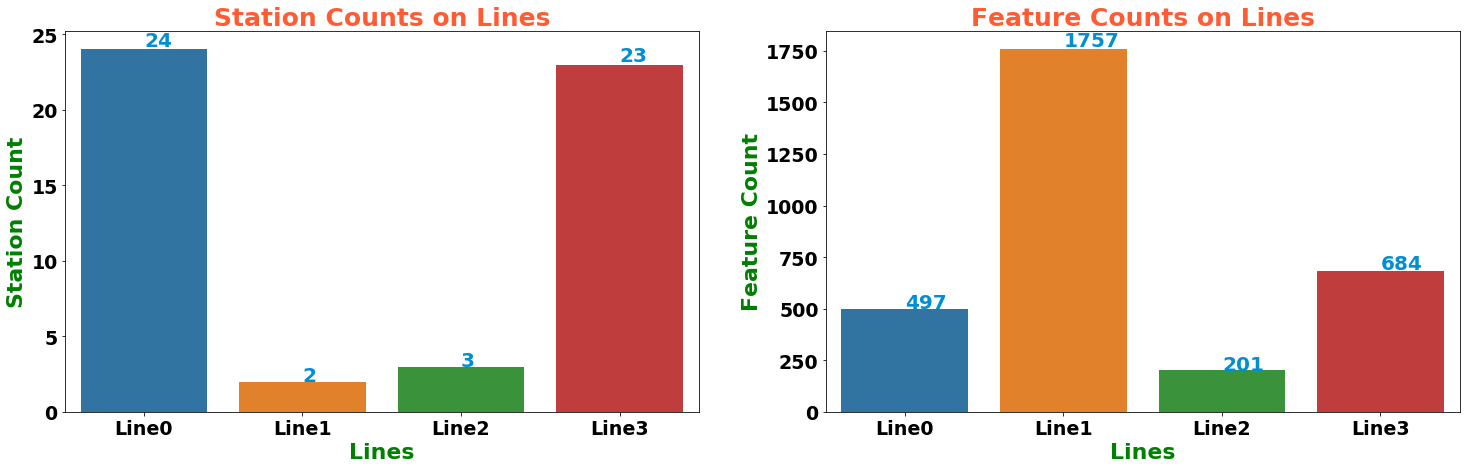

In [10]:
nrows=1
ncols=2
fig,ax=plt.subplots(nrows=nrows,ncols=ncols,figsize=(25,7))

def lineDetails(data,i,xlabel,ylabel,tittle,barvalue):
    g=sns.barplot(y=data,x=["Line0","Line1","Line2","Line3"],ax=ax[i])
    ax[i].set_xlabel(xlabel,fontsize=22,fontweight='bold',color='green')
    ax[i].set_ylabel(ylabel,fontsize=22,fontweight='bold',color='green')
    ax[i].set_title(tittle,fontsize=25,fontweight="bold",color="#ff5c33")
    plt.draw()
    ax[i].set_xticklabels(ax[i].get_xticklabels(),fontsize=19,fontweight="bold")
    ax[i].set_yticklabels(ax[i].get_yticklabels(),fontsize=19,fontweight="bold")
    
    k=0
    for p in g.patches:
        height=p.get_height()
        length=p.get_x()+p.get_width()/2
        g.text(length,1.01*height,barvalue[k],size=20,color='#008FD5',weight="bold")
        k+=1
        plt.draw()
    
lineDetails(station_count,0,"Lines","Station Count",
            "Station Counts on Lines",station_count)
lineDetails(feature_count,1,"Lines","Feature Count",
            "Feature Counts on Lines",feature_count)

In [11]:
feat0=[each.split("_")[1][1:] for each in line0]
feat0=dict(Counter(feat0))
key0=[k for k in feat0.keys()]
val0=[k for k in feat0.values()]
##
feat1=[each.split("_")[1][1:] for each in line1]
feat1=dict(Counter(feat1))
key1=[k for k in feat1.keys()]
val1=[k for k in feat1.values()]
##
feat2=[each.split("_")[1][1:] for each in line2]
feat2=dict(Counter(feat2))
key2=[k for k in feat2.keys()]
val2=[k for k in feat2.values()]
##
feat3=[each.split("_")[1][1:] for each in line3]
feat3=dict(Counter(feat3))
key3=[k for k in feat3.keys()]
val3=[k for k in feat3.values()]

In [12]:
df0=pd.DataFrame(feat0,index=["Count",]).transpose()
df0["Line"]="Line-0"
df1=pd.DataFrame(feat1,index=["Count",]).transpose()
df1["Line"]="Line-1"
df2=pd.DataFrame(feat2,index=["Count",]).transpose()
df2["Line"]="Line-2"
df3=pd.DataFrame(feat3,index=["Count",]).transpose()
df3["Line"]="Line-3"
df=pd.concat([df0,df1,df2,df3])
df.reset_index(inplace=True)
df["Stations"]=df["index"].astype(int)
df=df.sort_values(by="Stations")

### PLOT OF FEATURE DISTRIBUTION OVER LINES AND STATIONS 

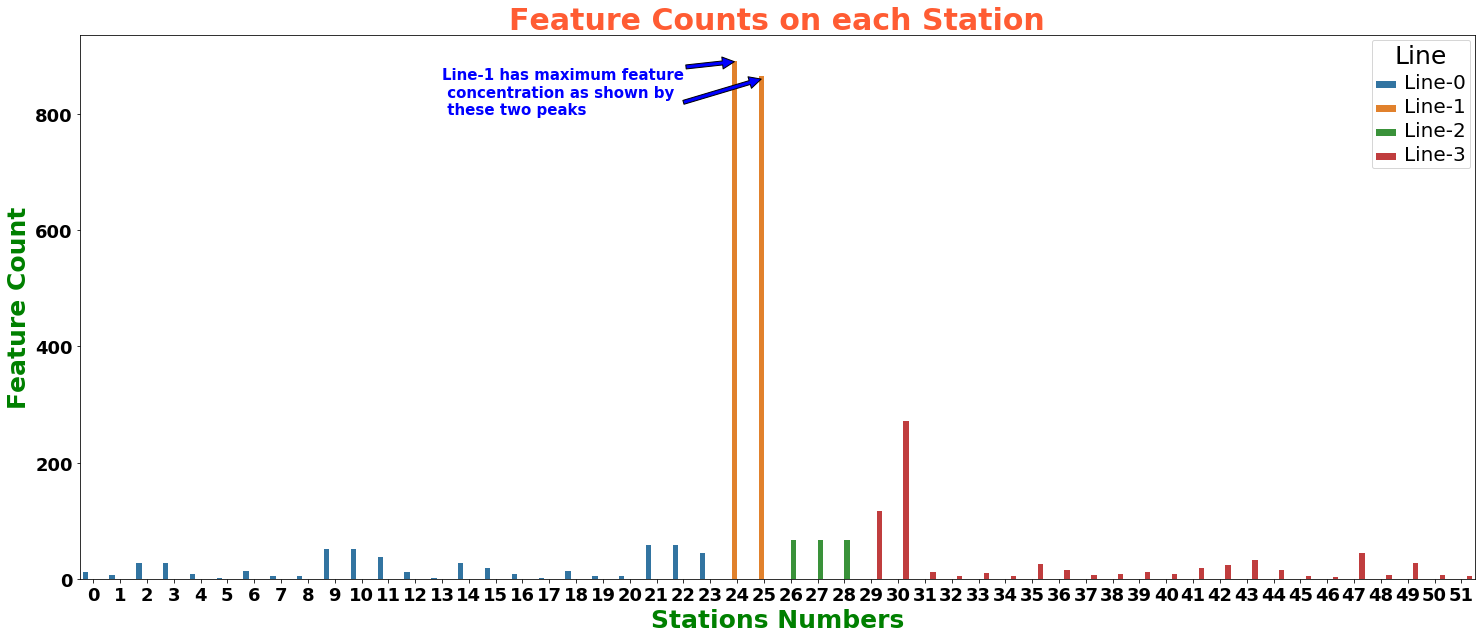

In [13]:
plot=sns.barplot(data=df,y="Count",x="Stations",hue="Line")
plt.gcf().set_size_inches(25,10)
plt.xlabel("Stations Numbers",fontsize=25,fontweight="bold",color="green")
plt.ylabel("Feature Count",fontsize=25,fontweight="bold",color="green")
plt.xticks(fontsize=18,fontweight="bold")
plt.yticks(fontsize=18,fontweight="bold")
plt.title("Feature Counts on each Station",fontsize=30,fontweight="bold",color="#ff5c33")
plt.setp(plot.get_legend().get_texts(),fontsize=20)
plt.setp(plot.get_legend().get_title(),fontsize=25)
#plt.text(x=10,y=800,s="Line-1 has maximum features\n as shown by these two peaks",
 #        color='blue',fontweight='bold',fontsize=15)

plt.annotate("Line-1 has maximum feature\n concentration as shown by\n these two peaks", 
             xy=(23.9,890),color='blue',fontsize=15,xytext=(13,800),fontweight='bold',
             arrowprops=dict(facecolor='blue', shrink=0.0001))

plt.annotate("",xy=(24.9,860),color='blue',fontsize=15,xytext=(22,820),
             arrowprops=dict(facecolor='blue', shrink=0.0001))

plt.show()